# Student Performance EDA

## Import Libraries and Load the data

In [72]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
import warnings

warnings.filterwarnings('ignore')

In [73]:
dataset_path=Path('../data/raw/StudentPerformanceFactors.csv')
df=pd.read_csv(dataset_path)

## Data Preparation and Cleaning
1. Look at some info about the data and columns
2. Fix any wrong data type
3. Fix any missing or incorrect data
4. Fix any duplicate data

In [74]:
df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


In [75]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [76]:
# converting the boolean features
bool_cols=['Extracurricular_Activities','Internet_Access','Learning_Disabilities']
for i in bool_cols:
    df[i] = df[i].map({'Yes': True, 'No': False})

In [77]:
df.isnull().mean()*100

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

In [78]:
# filling the missing categorical features
missing_cols=['Teacher_Quality','Parental_Education_Level','Distance_from_Home']
for i in missing_cols:
    df[i]=df[i].fillna(df[i].mode()[0])

In [79]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Hours_Studied,6607.0,19.975329,5.990594,1.0,16.0,20.0,24.0,44.0
Attendance,6607.0,79.977448,11.547475,60.0,70.0,80.0,90.0,100.0
Sleep_Hours,6607.0,7.029060,1.468120,4.0,6.0,7.0,8.0,10.0
Previous_Scores,6607.0,75.070531,14.399784,50.0,63.0,75.0,88.0,100.0
Tutoring_Sessions,6607.0,1.493719,1.230570,0.0,1.0,1.0,2.0,8.0
Physical_Activity,6607.0,2.967610,1.031231,0.0,2.0,3.0,4.0,6.0
Exam_Score,6607.0,67.235659,3.890456,55.0,65.0,67.0,69.0,101.0


In [80]:
df.duplicated().sum()

np.int64(0)

## Exploratory Analysis and Visualization
1. Analysis the target feature
2. Univariate analysis
2. bivariate analysis

### Exam Score

In [81]:
df.Exam_Score

0       67
1       61
2       74
3       71
4       70
        ..
6602    68
6603    69
6604    68
6605    68
6606    64
Name: Exam_Score, Length: 6607, dtype: int64

<Axes: xlabel='Exam_Score', ylabel='Count'>

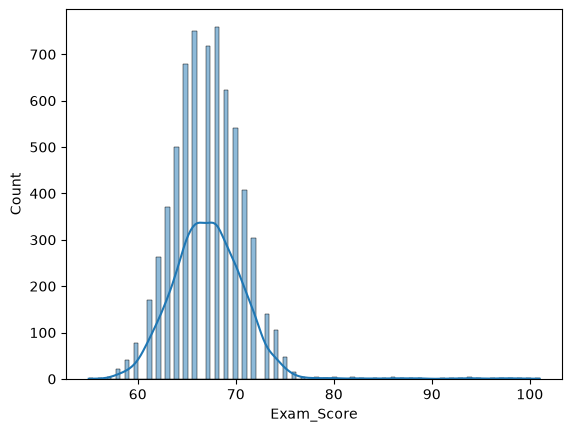

In [102]:
sns.histplot(data=df,x='Exam_Score',kde=True,bins=100)

<Axes: xlabel='Exam_Score'>

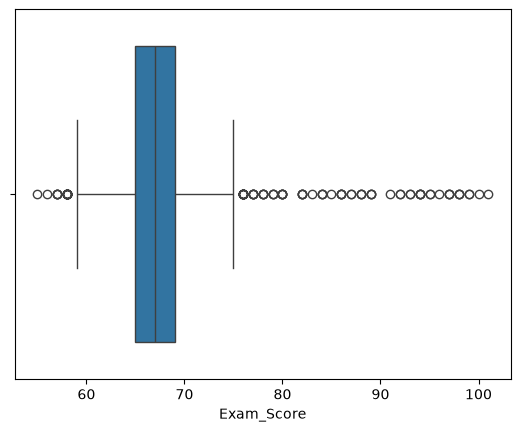

In [85]:
sns.boxplot(data=df,x='Exam_Score')

### Hours_Studied

<Axes: xlabel='Hours_Studied', ylabel='Count'>

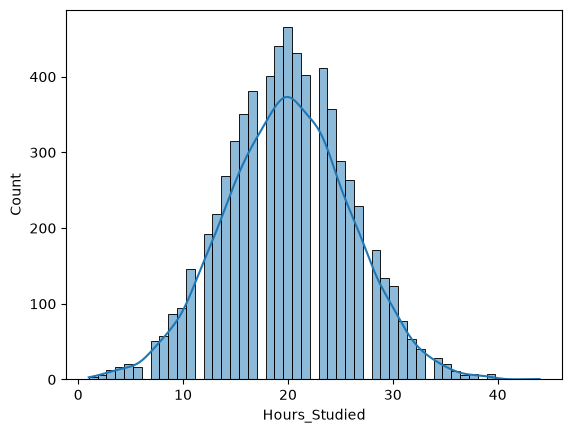

In [111]:
sns.histplot(data=df,x='Hours_Studied',kde=True)

### Attendance

<Axes: xlabel='Attendance', ylabel='Count'>

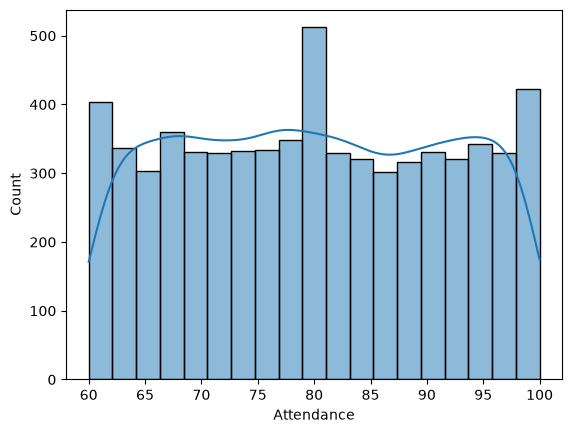

In [112]:
sns.histplot(data=df,x='Attendance',kde=True)

### Parental_Involvement

In [92]:
df.Parental_Involvement.value_counts()

Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

<Axes: xlabel='Parental_Involvement', ylabel='count'>

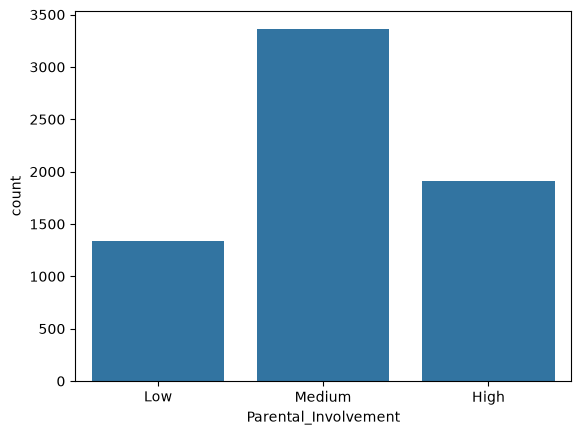

In [98]:
sns.countplot(data=df,x='Parental_Involvement')

### Access_to_Resources

In [103]:
df.Access_to_Resources.value_counts()

Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

<Axes: xlabel='Access_to_Resources', ylabel='count'>

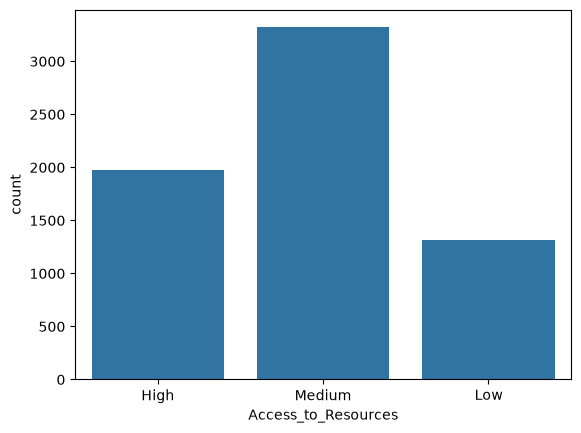

In [104]:
sns.countplot(data=df,x='Access_to_Resources')

### Extracurricular_Activities

In [105]:
df.Extracurricular_Activities.value_counts()

Extracurricular_Activities
True     3938
False    2669
Name: count, dtype: int64

<Axes: xlabel='Extracurricular_Activities', ylabel='count'>

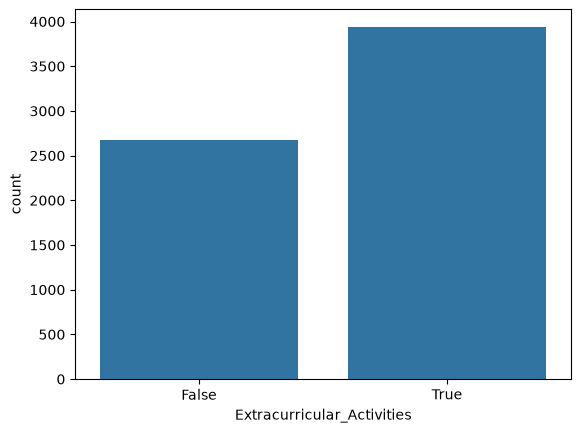

In [106]:
sns.countplot(data=df,x='Extracurricular_Activities')

### Sleep_Hours

<Axes: xlabel='Sleep_Hours', ylabel='Count'>

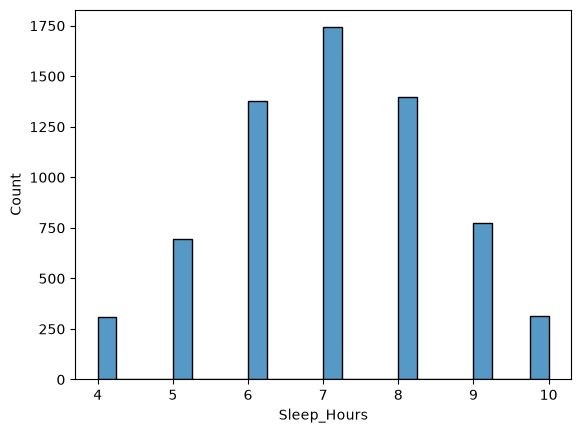

In [108]:
sns.histplot(data=df,x='Sleep_Hours',bins=24)

### Previous_Scores

<Axes: xlabel='Previous_Scores', ylabel='Count'>

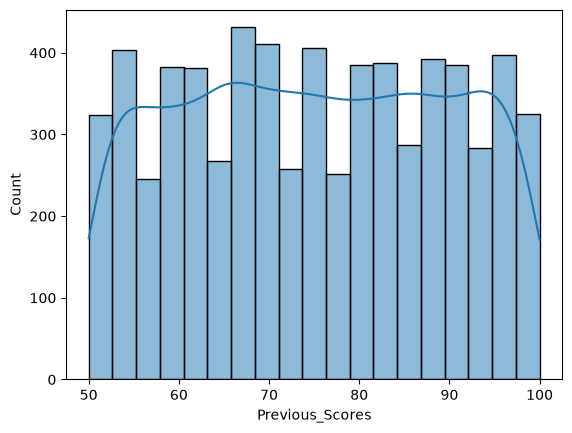

In [110]:
sns.histplot(data=df,x='Previous_Scores',kde=True)

### Motivation_Level

In [113]:
df.Motivation_Level.value_counts()

Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

<Axes: xlabel='Motivation_Level', ylabel='count'>

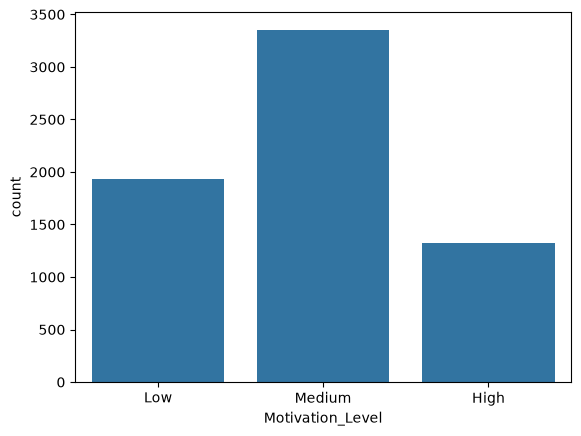

In [114]:
sns.countplot(data=df,x='Motivation_Level')

### Internet_Access

In [115]:
df.Internet_Access.value_counts()

Internet_Access
True     6108
False     499
Name: count, dtype: int64

<Axes: xlabel='Internet_Access', ylabel='count'>

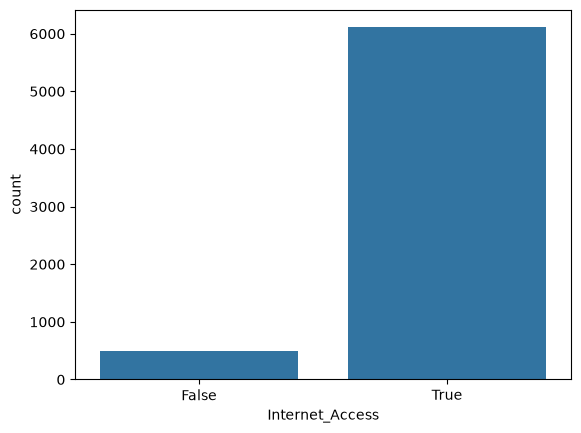

In [116]:
sns.countplot(data=df,x='Internet_Access')

### Tutoring_Sessions

<Axes: xlabel='Tutoring_Sessions', ylabel='Count'>

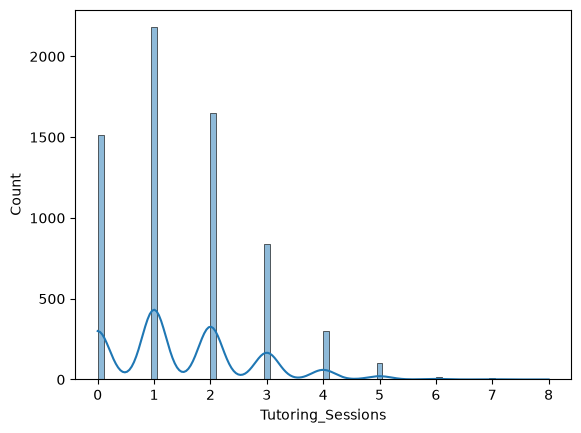

In [124]:
sns.histplot(data=df,x='Tutoring_Sessions', kde=True)

### Family_Income

In [125]:
df.Family_Income.value_counts()

Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

<Axes: xlabel='Family_Income', ylabel='count'>

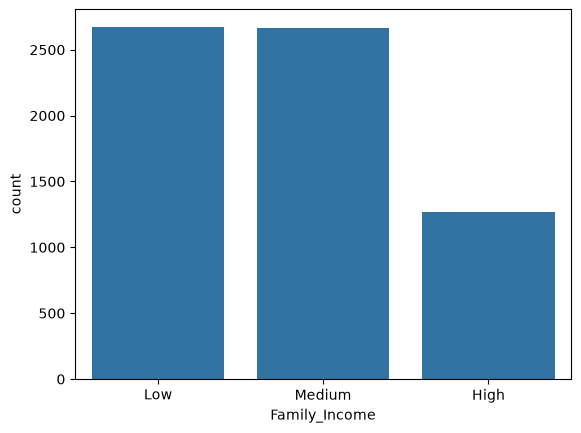

In [126]:
sns.countplot(data=df,x='Family_Income')

### Teacher_Quality

In [127]:
df.Teacher_Quality.value_counts()

Teacher_Quality
Medium    4003
High      1947
Low        657
Name: count, dtype: int64

<Axes: xlabel='Teacher_Quality', ylabel='count'>

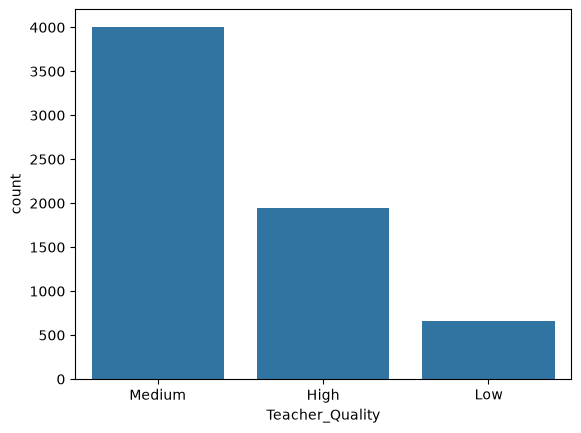

In [128]:
sns.countplot(data=df, x='Teacher_Quality')

### School_Type

In [129]:
df.School_Type.value_counts()

School_Type
Public     4598
Private    2009
Name: count, dtype: int64

<Axes: xlabel='School_Type', ylabel='count'>

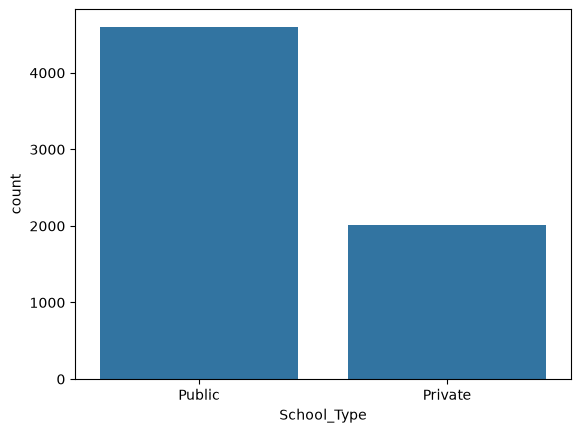

In [130]:
sns.countplot(data=df,x='School_Type')

### Peer_Influence

In [131]:
df.Peer_Influence.value_counts()

Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

<Axes: xlabel='Peer_Influence', ylabel='count'>

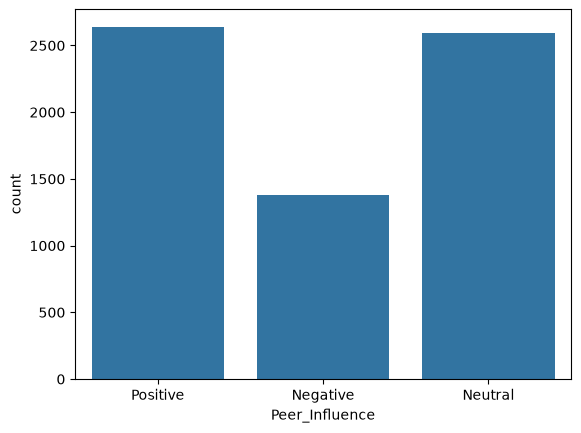

In [132]:
sns.countplot(data=df,x='Peer_Influence')

### Physical_Activity

<Axes: xlabel='Physical_Activity', ylabel='Count'>

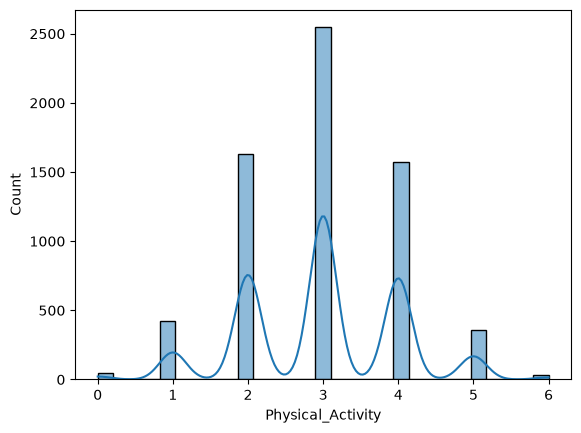

In [134]:
sns.histplot(data=df,x='Physical_Activity',kde=True)

### Learning_Disabilities

In [135]:
df.Learning_Disabilities.value_counts()

Learning_Disabilities
False    5912
True      695
Name: count, dtype: int64

<Axes: xlabel='Learning_Disabilities', ylabel='count'>

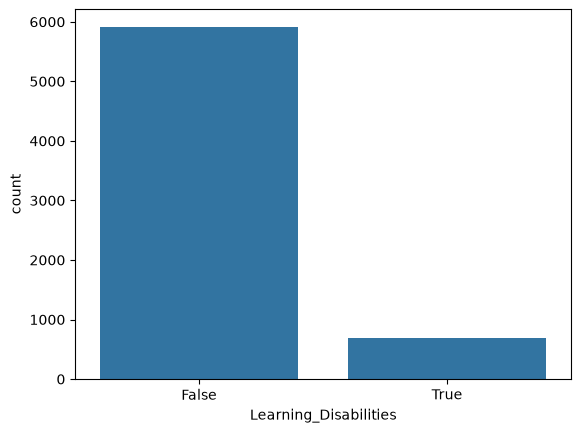

In [136]:
sns.countplot(data=df,x='Learning_Disabilities')

### Parental_Education_Level

In [137]:
df.Parental_Education_Level.value_counts()

Parental_Education_Level
High School     3313
College         1989
Postgraduate    1305
Name: count, dtype: int64

<Axes: xlabel='Parental_Education_Level', ylabel='count'>

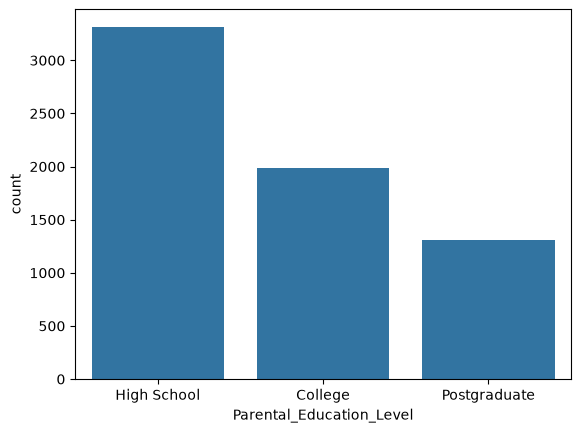

In [138]:
sns.countplot(data=df,x='Parental_Education_Level')

### Distance_from_Home

In [139]:
df.Distance_from_Home.value_counts()

Distance_from_Home
Near        3951
Moderate    1998
Far          658
Name: count, dtype: int64

<Axes: xlabel='Distance_from_Home', ylabel='count'>

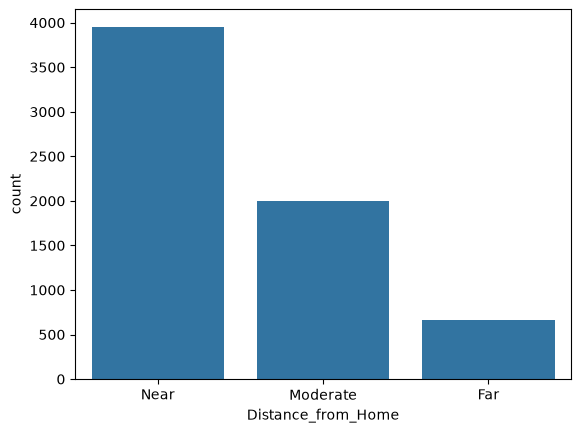

In [140]:
sns.countplot(data=df,x='Distance_from_Home')

### Gender

In [141]:
df.Gender.value_counts()

Gender
Male      3814
Female    2793
Name: count, dtype: int64

<Axes: xlabel='Gender', ylabel='count'>

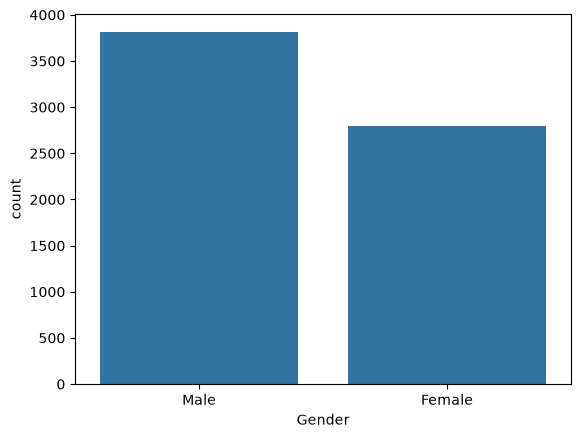

In [142]:
sns.countplot(data=df,x='Gender')

## Ask and Answer Questions
1. How does number of study hours affect Exam Score?
2. Which gender getting higher score

## Conclusion and Findings

- Maximum scores lie between 58 to 76
- Study Hour is Normally distributed and around 20 is maximum
- Attendance is distributed mostly evenly but 80% attendance is marginally higher.
- Parental Involvement is clearly seen in the dataset even though highest is Medium.